In [3]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras import layers, models
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc
import matplotlib.pyplot as plt
import seaborn as sns
import os
import time
import random
import cv2
from tensorflow.keras.preprocessing import image

d:\App\python\Lib\site-packages\keras\src\export\tf2onnx_lib.py:8: FutureWarning: In the future `np.object` will be defined as the corresponding NumPy scalar.
  if not hasattr(np, "object"):


In [ ]:
# Thiết lập các tham số
IMG_SIZE = 224  
BATCH_SIZE = 32
EPOCHS = 50

train_path = "../Data_Final/train"
val_path   = "../Data_Final/val"
test_path  = "../Data_Final/test"

In [5]:
# Kiểm tra GPU
print("GPU khả dụng: ", tf.config.list_physical_devices('GPU'))
print("Phiên bản TensorFlow:", tf.__version__)

GPU khả dụng:  []
Phiên bản TensorFlow: 2.20.0


In [6]:
# Tăng cường dữ liệu cho tập train
train_gen = ImageDataGenerator(
    rescale=1./255,
    # Giảm bias hình dạng / kích thước
    rotation_range=25,
    zoom_range=0.2,
    width_shift_range=0.1,
    height_shift_range=0.1,
    shear_range=0.15,
    horizontal_flip=True,
    fill_mode='nearest',
    # Giảm bias màu sắc
    brightness_range=[0.7, 1.3],
    channel_shift_range=30.0
)

# Chỉ rescale cho tập validation và test
val_gen = ImageDataGenerator(rescale=1./255)
test_gen = ImageDataGenerator(rescale=1./255)

# Nạp dữ liệu
train_data = train_gen.flow_from_directory(
    train_path,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode="categorical",
)

val_data = val_gen.flow_from_directory(
    val_path,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode="categorical",
)

test_data = test_gen.flow_from_directory(
    test_path,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    shuffle=False
)

class_names = list(train_data.class_indices.keys())

print(f"\nSố lượng lớp: {train_data.num_classes}")
print(f"Nhãn các lớp: {train_data.class_indices}")

Found 1966 images belonging to 2 classes.
Found 420 images belonging to 2 classes.
Found 424 images belonging to 2 classes.

Số lượng lớp: 2
Nhãn các lớp: {'fresh': 0, 'rotten': 1}


In [7]:
# Tải mô hình MobileNetV2 đã được huấn luyện trước
base_model = MobileNetV2(
    weights="imagenet",
    include_top=False,
    input_shape=(IMG_SIZE, IMG_SIZE, 3)
)

print(f"Mô hình cơ sở có {len(base_model.layers)} layers")

Mô hình cơ sở có 154 layers


In [8]:
# Giai đoạn 1: Đóng băng các layer, chỉ huấn luyện 30 layer cuối
for layer in base_model.layers[-30:]:
    layer.trainable = False

# Kiểm tra số lượng layer có thể huấn luyện
trainable_count = sum([1 for layer in base_model.layers if layer.trainable])
print(f"Số layer có thể huấn luyện: {trainable_count}/{len(base_model.layers)}")

Số layer có thể huấn luyện: 124/154


In [9]:
# Xây dựng mô hình
x = base_model.output
x = layers.GlobalAveragePooling2D()(x)
x = layers.BatchNormalization()(x)

x = layers.Dense(256, activation="relu")(x)
x = layers.Dropout(0.5)(x)

outputs = layers.Dense(
    train_data.num_classes,
    activation="softmax"
)(x)

model = models.Model(inputs=base_model.input, outputs=outputs)

model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1 (Conv2D)      │ (None, 112, 112,  │        864 │ input_layer[0][0] │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn_Conv1            │ (None, 112, 112,  │        128 │ Conv1[0][0]       │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1_relu (ReLU)   │ (None, 112, 112,  │          0 │ bn_Conv1[0][0]    │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        288 │ Conv1_relu[0][0]  │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        128 │ expanded_conv_de… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │          0 │ expanded_conv_de… │
│ (ReLU)              │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │        512 │ expanded_conv_de… │
│ (Conv2D)            │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │         64 │ expanded_conv_pr… │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand      │ (None, 112, 112,  │      1,536 │ expanded_conv_pr… │
│ (Conv2D)            │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_BN   │ (None, 112, 112,  │        384 │ block_1_expand[0… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_relu │ (None, 112, 112,  │          0 │ block_1_expand_B… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_pad         │ (None, 113, 113,  │          0 │ block_1_expand_r… │
│ (ZeroPadding2D)     │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise   │ (None, 56, 56,    │        864 │ block_1_pad[0][0] │
│ (DepthwiseConv2D)   │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │        384 │ block_1_depthwis… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │          0 │ block_1_depthwis… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_project     │ (None, 56, 56,    │      2,304 │ block_1_depthwis

 Total params: 2,591,554 (9.89 MB)

 Trainable params: 1,028,482 (3.92 MB)

 Non-trainable params: 1,563,072 (5.96 MB)

In [10]:
# Biên dịch mô hình
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

print("Mô hình đã được biên dịch thành công!")

Mô hình đã được biên dịch thành công!


In [11]:
# Thiết lập các callback
early_stop = EarlyStopping(
    monitor="val_loss",
    patience=7,
    restore_best_weights=True,
    verbose=1
)

reduce_lr = ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.3,
    patience=3,
    min_lr=1e-6,
    verbose=1
)

# Tạo thư mục để lưu mô hình
os.makedirs("../models", exist_ok=True)

checkpoint = ModelCheckpoint(
    "../models/mobilenetv2_best.keras",
    monitor="val_accuracy",
    save_best_only=True,
    mode="max",
    verbose=1
)

print("Đã cấu hình callbacks")

Đã cấu hình callbacks


In [12]:
# Train giai đoạn 1

start_time = time.time()

history = model.fit(
    train_data,
    validation_data=val_data,
    epochs=EPOCHS,
    callbacks=[early_stop, reduce_lr, checkpoint],
    verbose=1
)

# Giai đoạn 2: Fine - Tuning
for layer in base_model.layers[:-30]:
    layer.trainable = False
for layer in base_model.layers[-30:]:
    layer.trainable = True

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

history_fine = model.fit(
    train_data,
    validation_data=val_data,
    epochs=10,
    callbacks=[early_stop, reduce_lr],
    verbose=1
)

end_time = time.time()
print(f"Tổng thời gian huấn luyện: {end_time - start_time:.2f} giây")


Epoch 1/50
62/62 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.7537 - loss: 0.5438
Epoch 1: val_accuracy improved from None to 0.93810, saving model to ../models/mobilenetv2_best.keras

Epoch 1: finished saving model to ../models/mobilenetv2_best.keras
62/62 ━━━━━━━━━━━━━━━━━━━━ 184s 3s/step - accuracy: 0.8555 - loss: 0.3347 - val_accuracy: 0.9381 - val_loss: 0.2013 - learning_rate: 1.0000e-04
Epoch 2/50
62/62 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.9444 - loss: 0.1476
Epoch 2: val_accuracy did not improve from 0.93810
62/62 ━━━━━━━━━━━━━━━━━━━━ 173s 3s/step - accuracy: 0.9491 - loss: 0.1347 - val_accuracy: 0.8048 - val_loss: 0.3667 - learning_rate: 1.0000e-04
Epoch 3/50
62/62 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.9804 - loss: 0.0631
Epoch 3: val_accuracy did not improve from 0.93810
62/62 ━━━━━━━━━━━━━━━━━━━━ 170s 3s/step - accuracy: 0.9746 - loss: 0.0663 - val_accuracy: 0.9000 - val_loss: 0.2063 - learning_rate: 1.0000e-04
Epoch 4/50
62/62 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/ste

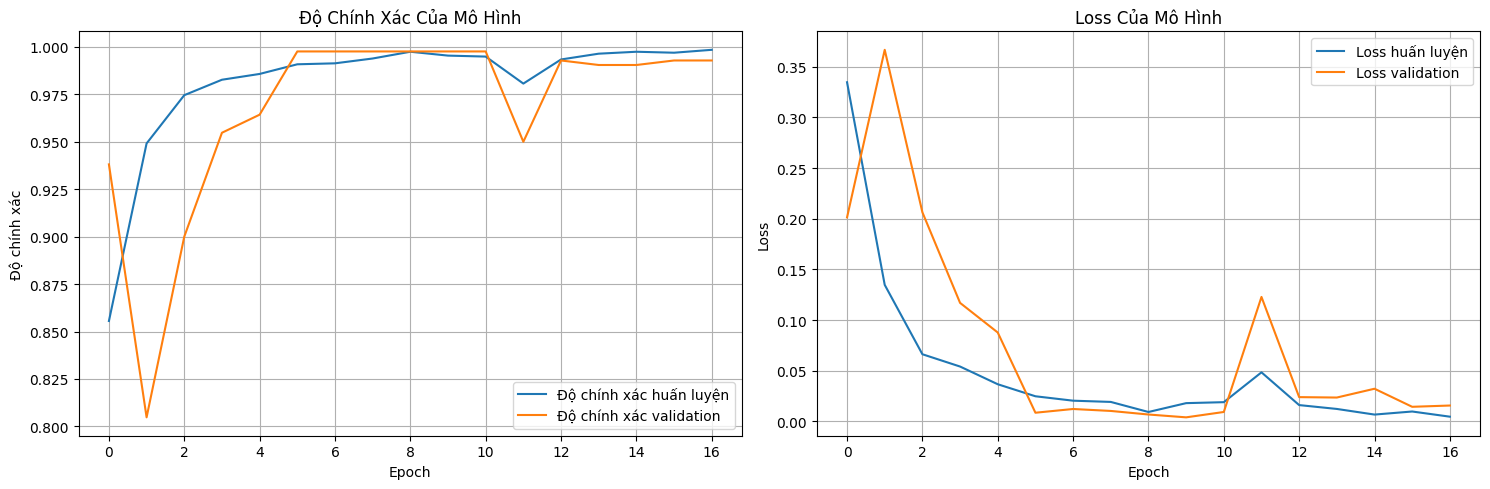

In [13]:
# Biểu đồ quá trình huấn luyện
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

# Vẽ biểu đồ độ chính xác
ax1.plot(history.history['accuracy'], label='Độ chính xác huấn luyện')
ax1.plot(history.history['val_accuracy'], label='Độ chính xác validation')
ax1.set_title('Độ Chính Xác Của Mô Hình')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Độ chính xác')
ax1.legend()
ax1.grid(True)

# Vẽ biểu đồ loss
ax2.plot(history.history['loss'], label='Loss huấn luyện')
ax2.plot(history.history['val_loss'], label='Loss validation')
ax2.set_title('Loss Của Mô Hình')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Loss')
ax2.legend()
ax2.grid(True)

plt.tight_layout()
plt.show()

In [14]:
# Đánh giá trên tập test
test_loss, test_accuracy = model.evaluate(test_data, verbose=1)

print(f"\nLoss trên tập test: {test_loss:.4f}")
print(f"Độ chính xác trên tập test: {test_accuracy:.4f}")

14/14 ━━━━━━━━━━━━━━━━━━━━ 8s 605ms/step - accuracy: 0.9929 - loss: 0.0224

Loss trên tập test: 0.0224
Độ chính xác trên tập test: 0.9929


In [15]:
# Dự đoán
predictions = model.predict(test_data)
predicted_classes = np.argmax(predictions, axis=1)
true_classes = test_data.classes
class_names = list(test_data.class_indices.keys())

print("\nClassification Report:\n")
print(classification_report(true_classes, predicted_classes, target_names=class_names))

14/14 ━━━━━━━━━━━━━━━━━━━━ 8s 531ms/step

Classification Report:

              precision    recall  f1-score   support

       fresh       0.99      0.99      0.99       195
      rotten       0.99      1.00      0.99       229

    accuracy                           0.99       424
   macro avg       0.99      0.99      0.99       424
weighted avg       0.99      0.99      0.99       424



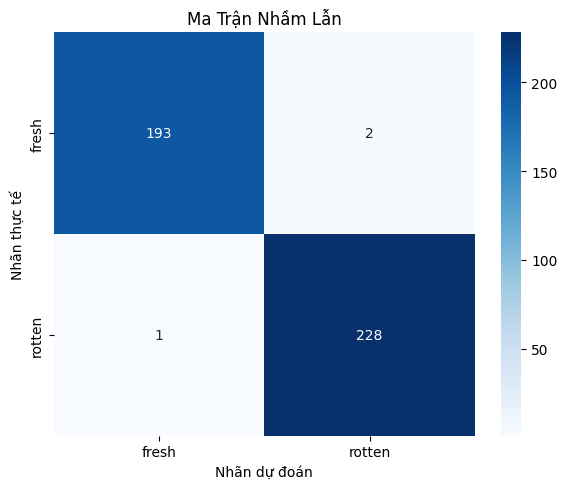


Độ Chính Xác Từng Lớp:
fresh: 98.97%
rotten: 99.56%


In [16]:
# Confusion Matrix
cm = confusion_matrix(true_classes, predicted_classes)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names,
            yticklabels=class_names)
plt.title('Ma Trận Nhầm Lẫn')
plt.ylabel('Nhãn thực tế')
plt.xlabel('Nhãn dự đoán')
plt.tight_layout()
plt.show()

# In độ chính xác cho từng lớp
print("\nĐộ Chính Xác Từng Lớp:")
for i, class_name in enumerate(class_names):
    class_accuracy = cm[i, i] / cm[i].sum() * 100
    print(f"{class_name}: {class_accuracy:.2f}%")

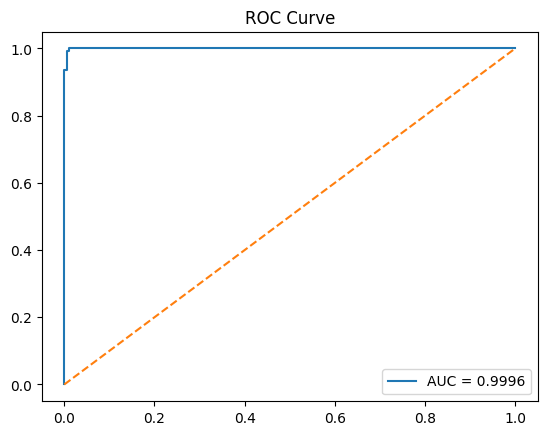

In [17]:
# ROC CURVE (2 lớp)
if len(class_names) == 2:
    fpr, tpr, _ = roc_curve(true_classes, predictions[:,1])
    roc_auc = auc(fpr, tpr)

    plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.4f}")
    plt.plot([0,1],[0,1],'--')
    plt.legend()
    plt.title("ROC Curve")
    plt.show()


Số ảnh dự đoán sai: 3


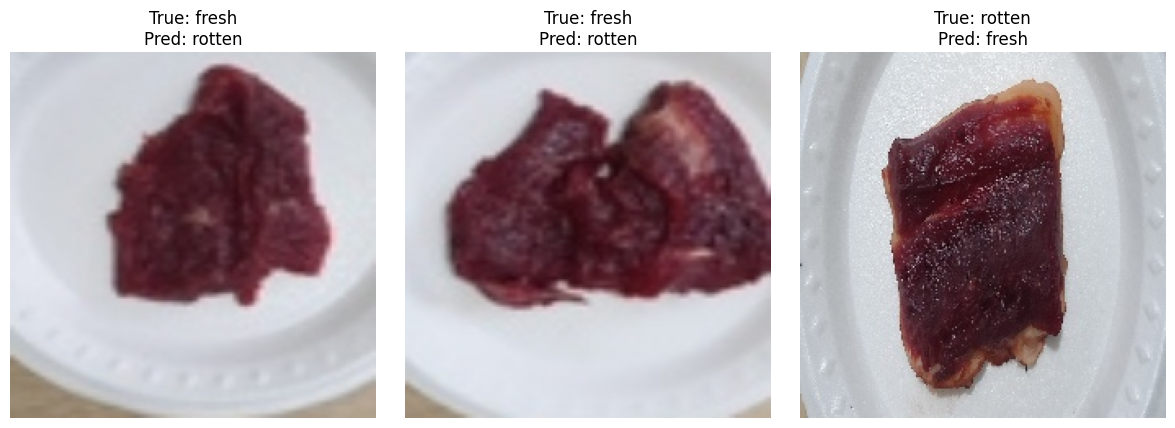

In [18]:
# ERROR ANALYSIS
misclassified = np.where(predicted_classes != true_classes)[0]
print(f"\nSố ảnh dự đoán sai: {len(misclassified)}")

plt.figure(figsize=(12,12))
for i, idx in enumerate(misclassified[:6]):
    img_path = test_data.filepaths[idx]
    img = plt.imread(img_path)

    plt.subplot(3,3,i+1)
    plt.imshow(img)
    plt.title(f"True: {class_names[true_classes[idx]]}\nPred: {class_names[predicted_classes[idx]]}")
    plt.axis('off')

plt.tight_layout()
plt.show()

In [20]:
# Lưu mô hình cuối cùng
model.save('../models/mobilenetv2_final.keras')
model.save('../models/mobilenetv2_final.h5')

print("\nĐã lưu mô hình thành công!")


Đã lưu mô hình thành công!
